In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

<font size="20" color="red">ch11.데이터 프래임과 시리즈(Pandas)</font>
- pip install pandas(아나콘다 프롬프트)

# 1절. 판다스 패키지
- 데이터 분석을 위해 반듯이 알아야할 패키지. 넘파이를 기반으로 하며, 다른 많은 라이브러리와 잘 통합되도록 설계
- 1차원 구조를 갖는 시리즈 / 2차원 구조를 갖는 프래임을 제공
- 판다스 장점 : 
        데이터 프래임 생성, 파일 i/o, 레이블링, 부분데이터추출, 크기변경(행이나 열삽입 삭제)
        데이터 분할, 병합, 데이터 정렬, 결측치 처리, 피벗과 언피벗 등이 용이
- https://pandas.pydata.org/docs/reference/index.html(API reference)

In [2]:
import pandas as pd
pd.__version__

'1.5.3'

In [4]:
data = pd.read_json('data/ch09_member1.json'
                   #,encoding='utf-8' 판다스read함수의 기본 encoding은 utf-8
                   )
display(data)
print(type(data))

,name,age,email,address
0,홍길동,20,kildong@hong.com,서울시 관악구
1,김길동,40,kimdong@hong.com,서울시 영등포구
2,신길동,30,sindong@hong.com,서울시 동작구


<class 'pandas.core.frame.DataFrame'>


In [5]:
member4 = pd.read_csv('data/ch09_member4.csv')# 해더가 있는 csv
member4

,name,age,email,address
0,홍길동,20,kildong@hong.com,서울시 관악구
1,김길동,40,kimdong@hong.com,서울시 영등포구
2,신길동,30,sindong@hong.com,서울시 동작구


In [8]:
member1 = pd.read_csv('data/ch09_member1.csv',
                      header=None,
                     names=['이름','나이','메일','주소'])
member1

,이름,나이,메일,주소
0,홍길동,20,kildong@hong.com,서울시 관악구
1,김길동,40,kimdong@hong.com,서울시 영등포구
2,신길동,30,sindong@hong.com,서울시 동작구


In [9]:
pd.read_hdf('data/ch09_iris.h5',key='iris')

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


# 2절. 데이터 프래임 만들기
## 2.1 딕셔너리를 이용해서 데이터 프래임 만들기

In [11]:
d = {'kor':[100,90],'mat':[95,99]}
df = pd.DataFrame(data=d)
df

,kor,mat
0,100,95
1,90,99


In [12]:
df.to_dict()# 데이터 프래임을 딕셔너리로 

{'kor': {0: 100, 1: 90}, 'mat': {0: 95, 1: 99}}

In [13]:
d = [{'kor':100,'mat':95},
    {'kor':90,'mat':99},]
df = pd.DataFrame(d) #데이터 프래임의 열은 동일 자료형
df

,kor,mat
0,100,95
1,90,99


In [15]:
df.dtypes #데이터 프래임의 열별 타입

kor    int64
mat    int64
dtype: object

In [16]:
df.info()#★

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   kor     2 non-null      int64
 1   mat     2 non-null      int64
dtypes: int64(2)
memory usage: 160.0 bytes


In [25]:
import numpy as np
df['kor'] = df['kor'].astype(np.float64) #데이터 프래임의 열타입 변경
df

,kor,mat
0,100.0,95
1,90.0,99


In [27]:
d = [{'kor':100,'mat':100},
     {'kor':90, 'mat':99},
     {'kor':83, 'eng':85}]
df = pd.DataFrame(data=d)
df

,kor,mat,eng
0,100,100.0,NaN
1,90,99.0,NaN
2,83,NaN,85.0


In [29]:
type(np.nan) #결측치의 타입 : float

float

In [30]:
# 결측치는 int로 형변환 불가

## 2.2 리스트를 이용해서 데이터 프래임 만들기

In [31]:
kor = [100,90,80,70,60]
mat = [90,80,81,71,61]
df = pd.DataFrame({'kor':kor,'mat':mat})
df

,kor,mat
0,100,90
1,90,80
2,80,81
3,70,71
4,60,61


In [33]:
pd.DataFrame(np.c_[kor,mat],columns=['kor','mat'])

,kor,mat
0,100,90
1,90,80
2,80,81
3,70,71
4,60,61


In [36]:
l = [[100,90],[70,80]]
pd.DataFrame(l,columns=['국어','수학'])

,국어,수학
0,100,90
1,70,80


- data.go.kr에서 "상가상권 정보"다운로드/ "민간 아파트 분양가격" 다운로드

In [42]:
%ls C:\ai\downloads\shareData\상가정보

 C 드라이브의 볼륨에는 이름이 없습니다.
 볼륨 일련 번호: 0C81-36F7

 C:\ai\downloads\shareData\상가정보 디렉터리

2026-07-14  오후 05:34    <DIR>          .
2026-07-14  오후 05:39    <DIR>          ..
2025-11-03  오전 12:45             1,011 [필독]파일열람방법.txt
2026-04-27  오전 11:10        61,321,696 소상공인시장진흥공단_상가(상권)정보_강원_202603.csv
2026-04-27  오전 11:10       367,852,181 소상공인시장진흥공단_상가(상권)정보_경기_202603.csv
2026-04-27  오전 11:10        92,474,293 소상공인시장진흥공단_상가(상권)정보_경남_202603.csv
2026-04-27  오전 11:10        76,309,810 소상공인시장진흥공단_상가(상권)정보_경북_202603.csv
2026-04-27  오전 11:10        40,031,721 소상공인시장진흥공단_상가(상권)정보_광주_202603.csv
2026-04-27  오전 11:10        61,825,564 소상공인시장진흥공단_상가(상권)정보_대구_202603.csv
2026-04-27  오전 11:10        41,866,930 소상공인시장진흥공단_상가(상권)정보_대전_202603.csv
2026-04-27  오전 11:10        84,329,596 소상공인시장진흥공단_상가(상권)정보_부산_202603.csv
2026-04-27  오전 11:10       292,646,735 소상공인시장진흥공단_상가(상권)정보_서울_202603.csv
2026-04-27  오전 11:10         9,651,297 소상공인시장진흥공단_상가(상권)정보_세종_202603.csv
2026-04-27  오전 11:10        28,285,232 소상공인시장진흥공단

In [47]:
df = pd.read_csv(r'C:\ai\downloads\shareData\상가정보\소상공인시장진흥공단_상가(상권)정보_세종_202603.csv',
                #encoding='utf8',sep=',',
                nrows = 30, #처음 30행만 가져오기
                low_memory=False, #데이터 용량이 클경우 기입
                )
df.shape

(30, 39)

In [50]:
# 판다스 디스플래이 옵션
pd.options.display.max_columns = 39 # 39열까지 display
pd.options.display.max_rows = 40 # 40행까지 display

In [52]:
df.head(2).T

,0,1
상가업소번호,MA010120220813963449,MA010120220805872513
상호명,레인카페,수와마을
지점명,NaN,NaN
상권업종대분류코드,I2,I2
상권업종대분류명,음식,음식
상권업종중분류코드,I212,I201
상권업종중분류명,비알코올,한식
상권업종소분류코드,I21201,I20101
상권업종소분류명,카페,백반/한정식
표준산업분류코드,I56229,I56111


## 2.3 read_csv

In [135]:
# (1) csv 파일 불러오기 (기본값)
import pandas as pd
member = pd.read_csv('data/ch11_member.csv')
member

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30
5,#홍길뜽,24,non@not.com,없는구,2000-01-01


In [136]:
member.info() #★

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Name     6 non-null      object
 1   Age      6 non-null      int64 
 2   Email    6 non-null      object
 3   Address  6 non-null      object
 4   Birth    6 non-null      object
dtypes: int64(1), object(4)
memory usage: 368.0+ bytes


In [137]:
# 문자형으로 변환
member['Age']=member['Age'].astype('str')
member['Age'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 6 entries, 0 to 5
Series name: Age
Non-Null Count  Dtype 
--------------  ----- 
6 non-null      object
dtypes: object(1)
memory usage: 176.0+ bytes


In [138]:
# 숫자형으로 변환
import numpy as np
member['Age']=member['Age'].astype('int16')
member['Age']=member['Age'].astype(np.int16)
member['Age']=pd.to_numeric(member['Age'],
              downcast='integer', #빼면 int32나 float64로 자동변환
              errors='coerce')   #숫자로 바꿀수 없는 데이터는 결측지로 변환ex)3,000
member.dtypes

Name       object
Age          int8
Email      object
Address    object
Birth      object
dtype: object

In [139]:
# 문자로 읽어들인 Birth를 datetime형으로 
member['Birth']=member['Birth'].astype('datetime64[ns]')
member = member.astype({'Birth':'datetime64[ns]','Age':'int32'})
# 01-01-1999,19990101
member['Birth'] = pd.to_datetime(member['Birth'], 
                              # format=%Y-%m-%d %H:%M:%S
                              )
member.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Name     6 non-null      object        
 1   Age      6 non-null      int32         
 2   Email    6 non-null      object        
 3   Address  6 non-null      object        
 4   Birth    6 non-null      datetime64[ns]
dtypes: datetime64[ns](1), int32(1), object(3)
memory usage: 344.0+ bytes


In [140]:
member['year'] = member.Birth.dt.year
member['month'] = member.Birth.dt.month
member['day'] = member.Birth.dt.day

In [141]:
member

,Name,Age,Email,Address,Birth,year,month,day
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01,1999,1,1
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01,1999,12,1
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01,1999,11,1
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01,1999,5,1
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30,1999,1,30
5,#홍길뜽,24,non@not.com,없는구,2000-01-01,2000,1,1


In [142]:
current_date = pd.to_datetime('2026-07-15')
member['일수']=(current_date - member.Birth).dt.days
member

,Name,Age,Email,Address,Birth,year,month,day,일수
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01,1999,1,1,10057
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01,1999,12,1,9723
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01,1999,11,1,9753
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01,1999,5,1,9937
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30,1999,1,30,10028
5,#홍길뜽,24,non@not.com,없는구,2000-01-01,2000,1,1,9692


In [143]:
# (2)특정행을 제외하고 cp949 encoding 파일 읽어오기
member = pd.read_csv('data/ch11_membercp949.csv',
                    encoding='cp949',
                    skiprows=[1,6]) #1행과 6행 제외하고 읽어오기
member

,Name,Age,Email,Address,Birth
0,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
1,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
2,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
3,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [144]:
#(3) sep ='|',주석(#)은 제외하고,상위 몇행만, datetime형 필드지정
member_df = pd.read_csv('data/ch11_membersep.csv',
                       sep ='|',             # |             
                       comment='#',
                       nrows=3,
                       parse_dates=['Birth'])
member_df

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01


In [145]:
member.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Name     4 non-null      object
 1   Age      4 non-null      int64 
 2   Email    4 non-null      object
 3   Address  4 non-null      object
 4   Birth    4 non-null      object
dtypes: int64(1), object(4)
memory usage: 288.0+ bytes


In [146]:
member_df = pd.read_csv('data/ch11_membertab.csv',
                       sep='\t',
                       comment='#',
                       parse_dates=['Birth'])
member_df

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


## 2.4 패키지에서 가져오기 : iris데이터
- iris가져오기 방법1 : sklearn(머신러닝 패키지)
- iris가져오기 방법2 : statsmodels(R 데이터)
- iris가져오기 방법3 : seaborn(시각화 패키지)

### 2.4.1 iris방법1 : sklearn
- sklearn.datasets 모듈 데이터(iris)를 데이터 프래임으로 변환 

In [147]:
from sklearn import datasets
# import sklearn.datasets as datasets : 머신러닝을 공부하기위한 학습용 데이터셋을 제공
# sklearn 패키지의 데이터셋 : 독립변수(입력변수)와 종속변수(타겟변수)가 분리된 딕셔너리 형태 제공
iris = datasets.load_iris() #딕셔너리 형태
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [148]:
print(iris.DESCR) # iris 데이터셋에 대한 설명

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                
    :Summary Statistics:

    ============== ==== ==== ======= ===== ====================
                    Min  Max   Mean    SD   Class Correlation
    ============== ==== ==== ======= ===== ====================
    sepal length:   4.3  7.9   5.84   0.83    0.7826
    sepal width:    2.0  4.4   3.05   0.43   -0.4194
    petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
    petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
    ============== ==== ==== ======= ===== ===========

In [149]:
iris.data #독립변수
iris['data'][:3]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2]])

In [150]:
iris.feature_names # 독립변수의 열이름
iris['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [151]:
# 데이터 프래임에서 독립변수 열이름 
[col[:-5].replace(' ','_') for col in iris.feature_names]

['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

In [152]:
[col[:12].strip().replace(' ','_') for col in iris.feature_names]

['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

In [153]:
# 종속변수(타겟변수)
iris.target
iris['target']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [154]:
iris.target_names
iris['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [155]:
# 데이터 프래임에 가장 오른쪽열(타겟변수-species)
iris.target_names[iris.target]
iris['target_names'][iris['target']]

array(['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolo

In [156]:
# 독립변수
data = iris.data
print(data[::50])
# 종속변수 : species
target = iris.target_names[iris.target].reshape(-1,1)
print(target[::50])

[[5.1 3.5 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.3 3.3 6.  2.5]]
[['setosa']
 ['versicolor']
 ['virginica']]


In [157]:
print('독립변수의 차원:',data.shape)
print('종속변수의 차원:',target.shape)

독립변수의 차원: (150, 4)
종속변수의 차원: (150, 1)


In [158]:
# ⓐ
import numpy as np
df = pd.DataFrame(np.hstack((data,target)),
                 columns=[col[:-5].replace(' ','_') for col in iris.feature_names]+['species'])
df.head(5) # 상위 5행만

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [159]:
df['petal_width']
df.petal_width[:3]

0    0.2
1    0.2
2    0.2
Name: petal_width, dtype: object

In [160]:
df = pd.DataFrame(np.hstack((data,target)),
                 columns= iris.feature_names+['species'])
df.head(3) # 상위 5행만

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa


In [161]:
df['petal width (cm)'][:3]
# df.petal width (cm)

0    0.2
1    0.2
2    0.2
Name: petal width (cm), dtype: object

In [162]:
#ⓑ 독립변수, 종속변수를 따로 데이터 프래임으로 생성한후 두 데이터 프래임을 연결
# X : 독립변수 데이터 프레임
X = pd.DataFrame(data,
                 columns=[col[:-5].replace(' ','_')for col in iris.feature_names])
X.head(1)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2


In [163]:
# y : 종속변수 데이터프래임
y = pd.DataFrame(target,columns=['species'])
y.tail() # 하위 5줄 

,species
145,virginica
146,virginica
147,virginica
148,virginica
149,virginica


In [164]:
print(X.index) # index : 행이름
print(y.index)

RangeIndex(start=0, stop=150, step=1)
RangeIndex(start=0, stop=150, step=1)


In [165]:
# 1. 두 데이터 프래임을 연결(열로 연결)
iris_df = pd.concat([X,y],axis=1)

In [166]:
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


### 2.4.2 iris방법2:statsmodels 패키지

In [167]:
from statsmodels.api import datasets
iris_dataset = datasets.get_rdataset('iris',
                                    package='datasets',
                                    cache=True) #데이터를 pc에 저장(~/statsmodels)
iris_dataset 

<class 'statsmodels.datasets.utils.Dataset'>

In [168]:
iris = iris_dataset.data
iris.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [169]:
iris['Sepal.Length'][:3]
# iris.Sepal.Length 불가

0    5.1
1    4.9
2    4.7
Name: Sepal.Length, dtype: float64

In [170]:
# 열이름 수정
[col.replace('.','-').lower() for col in iris.columns]

['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'species']

In [171]:
iris.columns = [col.replace('.','-').lower() for col in iris.columns]
iris.head(1)

,sepal-length,sepal-width,petal-length,petal-width,species
0,5.1,3.5,1.4,0.2,setosa


### 2.4.3 iris 방법3:seaborn

In [172]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head(1)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa


In [173]:
# 데이터 프래임을 파일로 출력하기
iris.to_csv('data/ch11_iris.csv', #4.01KB
#            sep=',',
#            encoding='utf-8',
           index=False)# 행이름이 생략되서 파일 출력

In [174]:
iris.to_csv('data/ch11_iris.zip',
           index=False,
           compression='infer') # 파일 확장자(.zip, .gz, .bz2등)를 보고 자동으로 압축형식을 추론해서 압축

In [175]:
load_iris = pd.read_csv('data/ch11_iris.zip',compression='infer')
load_iris.sample(3) #임의로3개

,sepal_length,sepal_width,petal_length,petal_width,species
149,5.9,3.0,5.1,1.8,virginica
80,5.5,2.4,3.8,1.1,versicolor
29,4.7,3.2,1.6,0.2,setosa


# 3절. 이름(열,행) 지정하기

## 3.1 열이름 지정하기

In [220]:
member = pd.read_csv('data/ch11_member.csv',comment='#',parse_dates=['Birth'])
member

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [222]:
member.columns #열이름

Index(['Name', 'Age', 'Email', 'Address', 'Birth'], dtype='object')

In [228]:
member.columns = ["이름","나이","이메일","주소","생년월일"]
member

,이름,나이,이메일,주소,생년월일
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


## 3.2 행이름 지정

In [229]:
member.index#행이름

RangeIndex(start=0, stop=5, step=1)

In [234]:
member.index =  ['동','서','남','북','중']
member

,이름,나이,이메일,주소,생년월일
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [236]:
member['이름']['서']

'홍길서'

In [237]:
member.loc['서','이름'] # loc[행이름, 열이름]으로 부분 데이터 조회(4절)

'홍길서'

In [238]:
member

,이름,나이,이메일,주소,생년월일
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [239]:
print(member.index)
print(member.index.name)

Index(['동', '서', '남', '북', '중'], dtype='object')
None


In [240]:
# 이름을 행이름 (실행결과가 출력되서 나오면 return될뿐,member가 안바뀜)
# member를 이름열을 행이름으로 수정(1)할당(2)inplace매개 변수에 True(기본값은 False)
member.set_index('이름',inplace=True)

In [241]:
member

,나이,이메일,주소,생년월일
이름,,,,
홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
홍길서,30,seo@hong.com,서울시 중구,1999-12-01
홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [242]:
print(member.index)
print(member.index.name)
print(member.columns)

Index(['홍길동', '홍길서', '홍길남', '홍길북', '홍길중'], dtype='object', name='이름')
이름
Index(['나이', '이메일', '주소', '생년월일'], dtype='object')


In [243]:
# 인덱스를 열에 편입시키기
#member.reset_index(inplace=True)
member = member.reset_index()

In [244]:
member.index = [0,11,2,3,4]
member

,이름,나이,이메일,주소,생년월일
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
11,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [245]:
# 기본 index를 0부터 새롭게 다시 numbering
member.index = range(len(member))#비추

In [246]:
member.index = [99,77,88,66,33]
#기존 index를 새로운 열에 편입시키지 않고 제거후 숫자 index를 초기화(추천)
member.reset_index(drop=True, inplace=True)

In [247]:
member

,이름,나이,이메일,주소,생년월일
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


## 3.3 레벨이름 지정하기

In [248]:
print(member.columns)
print(member.columns.name)
display(member)

Index(['이름', '나이', '이메일', '주소', '생년월일'], dtype='object')
None


,이름,나이,이메일,주소,생년월일
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [249]:
member.columns_name = '컬럼명'
member

,이름,나이,이메일,주소,생년월일
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [250]:
member.columns = [['기본정보','기본정보','기본정보','추가정보','추가정보'],
                 ['이름','나이','메일', '주소','생년월일']]
member.columns.names = ['대분류','소분류']
member

대분류 기본정보                        추가정보           
소분류   이름  나이             메일       주소       생년월일
0    홍길동  20  hong@hong.com  서울시 강동구 1999-01-01
1    홍길서  30   seo@hong.com   서울시 중구 1999-12-01
2    홍길남  21   nam@hong.com  서울시 강동구 1999-11-01
3    홍길북  22   buk@hong.com  서울시 관악구 1999-05-01
4    홍길중  23   mid@hong.com   부산시 중구 1999-01-30

In [251]:
member.index = [['좌우','좌우','상하','상하','상하'],
               ['동','서','남','북','중']]
member.index.names = ['레벨1','레벨2']
member

대분류     기본정보                        추가정보           
소분류       이름  나이             메일       주소       생년월일
레벨1 레벨2                                            
좌우  동    홍길동  20  hong@hong.com  서울시 강동구 1999-01-01
    서    홍길서  30   seo@hong.com   서울시 중구 1999-12-01
상하  남    홍길남  21   nam@hong.com  서울시 강동구 1999-11-01
    북    홍길북  22   buk@hong.com  서울시 관악구 1999-05-01
    중    홍길중  23   mid@hong.com   부산시 중구 1999-01-30

In [253]:
member[('기본정보','이름')]

레벨1  레벨2
좌우   동      홍길동
     서      홍길서
상하   남      홍길남
     북      홍길북
     중      홍길중
Name: (기본정보, 이름), dtype: object

In [254]:
member.loc['상하']

대분류 기본정보                       추가정보           
소분류   이름  나이            메일       주소       생년월일
레벨2                                           
남    홍길남  21  nam@hong.com  서울시 강동구 1999-11-01
북    홍길북  22  buk@hong.com  서울시 관악구 1999-05-01
중    홍길중  23  mid@hong.com   부산시 중구 1999-01-30

In [255]:
member.loc[('상하','남'),('기본정보','이름')]

'홍길남'

In [256]:
member.xs(key='남',level='레벨2')

대분류 기본정보                       추가정보           
소분류   이름  나이            메일       주소       생년월일
레벨1                                           
상하   홍길남  21  nam@hong.com  서울시 강동구 1999-11-01

In [260]:
member.loc['좌우','기본정보']

소분류,이름,나이,메일
레벨2,,,
동,홍길동,20,hong@hong.com
서,홍길서,30,seo@hong.com


# 4절. 부분 데이터 조회

In [264]:
member = pd.read_csv('data/ch11_member.csv',comment='#',parse_dates=['Birth'])
member

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


## 4.1 열조회
- df[열이름]
- df[조건]
- df[열이름들]

In [265]:
member['Name']
member.Name

0    홍길동
1    홍길서
2    홍길남
3    홍길북
4    홍길중
Name: Name, dtype: object

In [267]:
member[['Name','Age','Birth']]

,Name,Age,Birth
0,홍길동,20,1999-01-01
1,홍길서,30,1999-12-01
2,홍길남,21,1999-11-01
3,홍길북,22,1999-05-01
4,홍길중,23,1999-01-30


In [268]:
# member[0]행이름으로 조회할경우 loc사용

## 4.2 loc를 이용한 조회
- df.loc[행이름,열이름] : 행이름과 열이름으로 조회 
    * 행이름과 열이름 

In [269]:
member.loc[0:2] #0행부터 2행까지
member.loc[0:2,]
member.loc[0:2,:]
member.loc[0:2,...]
# 모든열을 출력할경우 생략 가능

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01


In [270]:
member.index = ['동','서','남','북','중']
member.loc['동':'남']

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01


In [271]:
# 동~남행까지 name~email
member.loc['동':'남','Name':'Email']

,Name,Age,Email
동,홍길동,20,hong@hong.com
서,홍길서,30,seo@hong.com
남,홍길남,21,nam@hong.com


In [272]:
# 동행과 남행만 조회
member.loc[['동','남']]

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01


In [273]:
# 동행과 남행의 Name과 Email만 조회
member.loc[['동','남'],['Name','Email']]

,Name,Email
동,홍길동,hong@hong.com
남,홍길남,nam@hong.com


In [275]:
# 모든행의 Name열
member.loc[:,'Name'] #한열이나 한행은 결과가 1차원 시리즈
member.loc[...,'Name']

동    홍길동
서    홍길서
남    홍길남
북    홍길북
중    홍길중
Name: Name, dtype: object

In [277]:
member.loc[['동']]

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01


In [280]:
type(member.loc['동']),type(member.loc[:,'Name'])

(pandas.core.series.Series, pandas.core.series.Series)

## 4.3 iloc을 이용한 조회
- df.iloc[행번호,열번호]
    * 행번호, 열번호 자리에는 list,슬라이싱[from:stop:by] : from부터 stop앞까지 by씩
    * 열번호 생략시 모든 열 조회

In [281]:
member

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [284]:
# 2번째 부터 3번째 행 (0이 처음)
member.loc['남':'북']
member.iloc[2:4]

,Name,Age,Email,Address,Birth
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01


In [285]:
member.iloc[0] #1차원 시리즈

Name                       홍길동
Age                         20
Email            hong@hong.com
Address                서울시 강동구
Birth      1999-01-01 00:00:00
Name: 동, dtype: object

In [286]:
type(member.iloc[0])

pandas.core.series.Series

In [289]:
# 0번째 ~2번째행, 1번째 ~2번째 열
member.iloc[0:3,1:3]

,Age,Email
동,20,hong@hong.com
서,30,seo@hong.com
남,21,nam@hong.com


In [291]:
# 0번째행과 2번째행, 1번째열과 3번째 열
member.iloc[[0,2],[1,3]]

,Age,Address
동,20,서울시 강동구
남,21,서울시 강동구


In [292]:
# 짝수번째 행(0,2,4번째)의 맨 마지막열을 재외하고 조회
member.iloc[::2,:-1]

,Name,Age,Email,Address
동,홍길동,20,hong@hong.com,서울시 강동구
남,홍길남,21,nam@hong.com,서울시 강동구
중,홍길중,23,mid@hong.com,부산시 중구


In [294]:
# 마지막행부터 처음행까지 꺼꾸로 출력
member.iloc[::-1]

,Name,Age,Email,Address,Birth
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01


## 4.4 조건으로 조회하기

In [295]:
member

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [296]:
member['Age']>=23

동    False
서     True
남    False
북    False
중     True
Name: Age, dtype: bool

In [298]:
member.loc[[False,True,False,False,True]]

,Name,Age,Email,Address,Birth
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [299]:
# 23세 이상의 데이터만 조회
member.loc[member['Age']>=23]
member.loc[member['Age']>=23,:]
member[member['Age']>=23]

,Name,Age,Email,Address,Birth
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [301]:
#23세 이상의 데이터중 Name,Age,Email
member.loc[member['Age']>=23,['Name','Email']]

,Name,Email
서,홍길서,seo@hong.com
중,홍길중,mid@hong.com


In [303]:
# 23세 이상이 아닌 데이터(모든열):~(반대)
member[~(member['Age']<23)]

,Name,Age,Email,Address,Birth
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [302]:
member[member['Age']<23]

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01


In [310]:
#관악구가 포함되어 있는지 
address = "서울시 관악구 신림동"
print(address.find('관악구')!=-1)
print(address.find('중구')!=-1)
#서울시로 시작되는지
print(address.startswith('서울시'))

True
False
True


In [ ]:
# member['address'].find('중구') =>시리즈에 문자함수를 바로 사용 x

※ 시리즈에 문자 함수를 쓰기위한 참조:https://pandas.pydata.org/pandas-docs/stable/reference/series.html#string-handling

In [314]:
member['Address'].str.find('중구')!=-1

동    False
서     True
남    False
북    False
중     True
Name: Address, dtype: bool

In [318]:
# Address에 중구가 포함된 데이터
member[member['Address'].str.find('중구')!=-1]
member.loc[member['Address'].str.find('중구')!=-1]
member.loc[member['Address'].str.find('중구')!=-1,:]

,Name,Age,Email,Address,Birth
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [322]:
#Address에 중구가 포함된 데이터의 Name,Age,Email
member.loc[member['Address'].str.find('중구')!=-1,'Name':'Email']
member.loc[member['Address'].str.find('중구')!=-1,['Name','Age','Email']]

,Name,Age,Email
서,홍길서,30,seo@hong.com
중,홍길중,23,mid@hong.com


In [341]:
#Address가 중구인데이터
member[member['Address'].str.find('중구')!=-1]

,Name,Age,Email,Address,Birth
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
4,홍길중,23,NaN,부산시 중구,1999-01-30


In [342]:
#Address가 중구이거나 관악구인데이터
member[member['Address'].str.contains('중구|관악구')]

,Name,Age,Email,Address,Birth
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,NaN,부산시 중구,1999-01-30


In [324]:
#Address가 서울이 아닌 데이터
member[~member['Address'].str.startswith('서울')]

,Name,Age,Email,Address,Birth
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [325]:
# Name이 홍길동이거나 홍길남이거나 홍길선인 데이터의 모든것
member[(member['Name']=='홍길동')|(member['Name']=='홍길남')|(member['Name']=='홍길서')]

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01


In [327]:
member[member['Name'].isin(['홍길동','홍길남','홍길서'])]

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01


In [330]:
#Name이 홍길동이거나 홍길남이거나 홍길서인 Name,Age,Email
member.loc[member['Name'].isin(['홍길동','홍길남','홍길서']),['Name','Email']]
member.loc[member['Name'].isin(['홍길동','홍길남','홍길서']),['Name','Age','Email']]

,Name,Age,Email
동,홍길동,20,hong@hong.com
서,홍길서,30,seo@hong.com
남,홍길남,21,nam@hong.com


In [331]:
# 1월생인 데이터
member = pd.read_csv('data/ch11_member.csv',comment='#',parse_dates=['Birth'])
member[member['Birth'].dt.month==1]

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [332]:
# 1월생이면서 서울시인 데이터
member[(member.Birth.dt.month==1) & member.Address.str.startswith('서울시')]

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01


In [333]:
member

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [335]:
import numpy as np
member.loc[[2,4],'Email']=np.nan
member

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,NaN,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,NaN,부산시 중구,1999-01-30


In [336]:
member.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Name     5 non-null      object        
 1   Age      5 non-null      int64         
 2   Email    3 non-null      object        
 3   Address  5 non-null      object        
 4   Birth    5 non-null      datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 328.0+ bytes


In [338]:
member.isna() # 모든 행과 열에 결측치 여부

,Name,Age,Email,Address,Birth
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,True,False,False
3,False,False,False,False,False
4,False,False,True,False,False


In [340]:
# 각열의 결측치 갯수
member.isna().sum()

Name       0
Age        0
Email      2
Address    0
Birth      0
dtype: int64

In [343]:
# Email이 결측지인 행
member[member['Email'].isna()]

,Name,Age,Email,Address,Birth
2,홍길남,21,NaN,서울시 강동구,1999-11-01
4,홍길중,23,NaN,부산시 중구,1999-01-30


※ 데이터 프래임의 부분 데이터 조회방법
- df[열이름] - 특정열의 모든행 조회
- df[조건]   - 조건에 맞는 모든 행의 모든열 조회
- df.loc[행이름,열이름] : 행이름(조건)과 열이름으로 조회
    * 행이름 자리에 조건 가능
    * 행이름, 열이름 자리에 list,슬라이싱
    * 열이름 생략시 모든열
- df.iloc[행번호,열번호] : 번호로 조회
    * 행번호, 열번호 자리에 ilst,슬라이싱
    * 열번호 생략시 모든열

In [346]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head()
iris.iloc[::50]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
50,7.0,3.2,4.7,1.4,versicolor
100,6.3,3.3,6.0,2.5,virginica


In [349]:
# 1. sepal_length 열만 출력
iris['sepal_length']
iris.sepal_length

0      5.1
1      4.9
2      4.7
3      4.6
4      5.0
      ... 
145    6.7
146    6.3
147    6.5
148    6.2
149    5.9
Name: sepal_length, Length: 150, dtype: float64

In [357]:
# 2. 0~10행까지 마지막 열을 제외한 데이터 (loc, iloc)
iris.loc[0:10,'sepal_length':'petal_width'] 

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


In [360]:
iris.iloc[0:11,:-1]

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


In [388]:
# 3. 3~10 행중에 'sepal_length'와 'petal_length' 열만 (loc, iloc)
iris.loc[3:10,['sepal_length','petal_length']]

,sepal_length,petal_length
3,4.6,1.5
4,5.0,1.4
5,5.4,1.7
6,4.6,1.4
7,5.0,1.5
8,4.4,1.4
9,4.9,1.5
10,5.4,1.5


In [390]:
iris.iloc[3:10,[0,2]]

,sepal_length,petal_length
3,4.6,1.5
4,5.0,1.4
5,5.4,1.7
6,4.6,1.4
7,5.0,1.5
8,4.4,1.4
9,4.9,1.5


In [370]:
# 4. 0번째, 50번째, 100번째 행의 모든 열 (loc, iloc)
iris.loc[[0,50,100],:]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
50,7.0,3.2,4.7,1.4,versicolor
100,6.3,3.3,6.0,2.5,virginica


In [372]:
iris.iloc[::50,:]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
50,7.0,3.2,4.7,1.4,versicolor
100,6.3,3.3,6.0,2.5,virginica


In [ ]:
# 5. 0번째, 25, 50번째, 75번, 100번째, 125번째 행의 petal_length와 petal_width (loc, iloc)

In [373]:
iris.loc[::25,'petal_length':'petal_width']

,petal_length,petal_width
0,1.4,0.2
25,1.6,0.2
50,4.7,1.4
75,4.4,1.4
100,6.0,2.5
125,6.0,1.8


In [375]:
iris.iloc[::25,2:4]

,petal_length,petal_width
0,1.4,0.2
25,1.6,0.2
50,4.7,1.4
75,4.4,1.4
100,6.0,2.5
125,6.0,1.8


In [392]:
# 6. species가 versicolor인 데이터의 모든 열
iris[iris.species=='versicolor']
iris[iris['species']=='versicolor']
iris[iris['species'].str.contains('versicolor')]

,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,versicolor
51,6.4,3.2,4.5,1.5,versicolor
52,6.9,3.1,4.9,1.5,versicolor
53,5.5,2.3,4.0,1.3,versicolor
54,6.5,2.8,4.6,1.5,versicolor
55,5.7,2.8,4.5,1.3,versicolor
56,6.3,3.3,4.7,1.6,versicolor
57,4.9,2.4,3.3,1.0,versicolor
58,6.6,2.9,4.6,1.3,versicolor
59,5.2,2.7,3.9,1.4,versicolor


In [400]:
# 7. species가 setosa인 데이터 최초 5개 행만 출력
iris[iris.species=='setosa'].head()
iris[iris['species']=='setosa'].iloc[:5]
# iris[iris['species'].str.contains('versicolor')]
# iris.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [393]:
# 8. sepal_length가 6.5이상인 데이터 최초 5개 행만 출력
# iris[iris['sepal_length']>=6.5]
# iris.head(5)
iris[iris.sepal_length>=6.5].head()
iris[iris['sepal_length']>=6.5].iloc[:5]

,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,versicolor
52,6.9,3.1,4.9,1.5,versicolor
54,6.5,2.8,4.6,1.5,versicolor
58,6.6,2.9,4.6,1.3,versicolor
65,6.7,3.1,4.4,1.4,versicolor


In [397]:
# 9. sepal_length가 7.2이상인 데이터의 'sepal_length'와 'sepal_width'와 'petal_length'
iris.loc[iris['sepal_length']>=7.2,'sepal_length':'petal_length']
# iris.loc[iris['sepal_length']>=7.2, 'sepal_length':'petal_length']
# iris.loc[iris.sepal_length>=7.2, ['sepal_length','sepal_width','petal_length']]
# iris[iris['sepal_length']>=7.2][['sepal_length','sepal_width','petal_length']]


,sepal_length,sepal_width,petal_length
105,7.6,3.0,6.6
107,7.3,2.9,6.3
109,7.2,3.6,6.1
117,7.7,3.8,6.7
118,7.7,2.6,6.9
122,7.7,2.8,6.7
125,7.2,3.2,6.0
129,7.2,3.0,5.8
130,7.4,2.8,6.1
131,7.9,3.8,6.4


In [399]:
iris.loc[iris['sepal_length']>=7.2, 'sepal_length':'petal_length']
iris.loc[iris.sepal_length>=7.2, ['sepal_length','sepal_width','petal_length']]
iris[iris['sepal_length']>=7.2][['sepal_length','sepal_width','petal_length']]


,sepal_length,sepal_width,petal_length
105,7.6,3.0,6.6
107,7.3,2.9,6.3
109,7.2,3.6,6.1
117,7.7,3.8,6.7
118,7.7,2.6,6.9
122,7.7,2.8,6.7
125,7.2,3.2,6.0
129,7.2,3.0,5.8
130,7.4,2.8,6.1
131,7.9,3.8,6.4


In [398]:
# 10. versicolor종중에서 sepal_length가 6.5보다 큰 데이터의 모든 열
iris[ (iris.species=='versicolor') & (iris.sepal_length>6.5)]


,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,versicolor
52,6.9,3.1,4.9,1.5,versicolor
58,6.6,2.9,4.6,1.3,versicolor
65,6.7,3.1,4.4,1.4,versicolor
75,6.6,3.0,4.4,1.4,versicolor
76,6.8,2.8,4.8,1.4,versicolor
77,6.7,3.0,5.0,1.7,versicolor
86,6.7,3.1,4.7,1.5,versicolor


In [ ]:
iris[ (iris.species=='versicolor') & (iris.sepal_length>6.5)]


# 5절.데이터 삭제 및 추가
## 5.1 데이터 프레임의 요소삭제
- df.drop(열이름이나 행이름(label), axis) : axis=0일때는 행삭제,axis=1일때는 열삭제

In [3]:
import pandas as pd
member = pd.read_csv('data/ch11_member.csv',comment='#')
member.index = ['동','서','남','북','중']
member

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [4]:
# 1)단일행 삭제
member.drop('동')# axis=0(기본값)이면 행이름을 찾아 삭제한 결과를 반환한다.
                 # 삭제한 결과를 member에 적용 ⓐ할당 ⓑinplace=True 매개변수 추가

,Name,Age,Email,Address,Birth
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [6]:
member=member.drop('동')

In [9]:
# 2) 복수행 삭제
member.drop(['서','남'])#,axis=0생략

,Name,Age,Email,Address,Birth
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [10]:
# 3) 열삭제
member.drop(['Age','Birth'],axis=1,inplace=True)

In [11]:
member

,Name,Email,Address
서,홍길서,seo@hong.com,서울시 중구
남,홍길남,nam@hong.com,서울시 강동구
북,홍길북,buk@hong.com,서울시 관악구
중,홍길중,mid@hong.com,부산시 중구


## 5.2 데이터 프래임의 요소 추가
※열추가

In [51]:
member = pd.read_csv('data/ch11_member.csv',comment='#',parse_dates=['Birth'])
member['no']=7
member

,Name,Age,Email,Address,Birth,no
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01,7
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01,7
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01,7
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01,7
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30,7


In [52]:
 import numpy as np
# member['num']=[7,7,7]+[np.nan]*2
new_col = pd.Series([7,8,9],index=[0,1,4])
new_col

0    7
1    8
4    9
dtype: int64

In [53]:
member['num'] = new_col
member

,Name,Age,Email,Address,Birth,no,num
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01,7,7.0
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01,7,8.0
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01,7,NaN
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01,7,NaN
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30,7,9.0


In [54]:
member['출생년도'] = member['Birth'].dt.year
member

,Name,Age,Email,Address,Birth,no,num,출생년도
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01,7,7.0,1999
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01,7,8.0,1999
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01,7,NaN,1999
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01,7,NaN,1999
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30,7,9.0,1999


※행추가

In [55]:
member = pd.read_csv('data/ch11_member.csv',comment='#')
member

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [56]:
new_member = pd.DataFrame([{'Name':'홍길숙',
                           'Age':29,
                           'Email':'suk@hong.com',
                           'Address':'서울시',
                           'Birth':'2000-01-01'},
                        {'Name':'홍길숙',
                           'Age':29,
                           'Email':'suk@hong.com',
                           'Address':'서울시',
                           'Birth':'2000-01-01'}  ])
new_member

,Name,Age,Email,Address,Birth
0,홍길숙,29,suk@hong.com,서울시,2000-01-01
1,홍길숙,29,suk@hong.com,서울시,2000-01-01


In [57]:
# 데이터 프래임 연결
member=pd.concat([member,new_member],axis=0) # axis=0기본값

In [60]:
member.reset_index(drop=True,inplace=True)

In [61]:
new_Series = pd.Series(['이상함',-20,'l@l.com','이상한나라','1000-01-01'],
                      index=member.columns)
pd.DataFrame(new_Series).T

,Name,Age,Email,Address,Birth
0,이상함,-20,l@l.com,이상한나라,1000-01-01


In [62]:
pd.concat([member,pd.DataFrame(new_Series).T]).reset_index(drop=True)

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30
5,홍길숙,29,suk@hong.com,서울시,2000-01-01
6,홍길숙,29,suk@hong.com,서울시,2000-01-01
7,이상함,-20,l@l.com,이상한나라,1000-01-01


# 6절. 병합과 연결
## 6.1 merge()를 이용한 데이터 프래임 병합

In [63]:
df1=pd.DataFrame({'key':['a','b','c','d'],
                  'c1 ':[1,2,3,4]})
df2=pd.DataFrame({'key':['a','b','c','f'],
                  'c2' :[5,6,7,8]})
display(df1)
display(df2)

,key,c1
0,a,1
1,b,2
2,c,3
3,d,4


,key,c2
0,a,5
1,b,6
2,c,7
3,f,8


In [64]:
df1.merge(df2) #how = 'inner': 내부조인(양쪽다 일치하는 데이터만 병합)

,key,c1,c2
0,a,1,5
1,b,2,6
2,c,3,7


In [65]:
df1.merge(df2,how='left')#왼쪽데이터는 모두 남기고 오른쪽 df2를 병합

,key,c1,c2
0,a,1,5.0
1,b,2,6.0
2,c,3,7.0
3,d,4,NaN


In [66]:
df1.merge(df2,how='right')#오른쪽데이터는 모두 남기고 오른쪽 df1를 병합

,key,c1,c2
0,a,1.0,5
1,b,2.0,6
2,c,3.0,7
3,f,NaN,8


In [67]:
df1.merge(df2,how='outer')#양쪽데이터는 모두 남김

,key,c1,c2
0,a,1.0,5.0
1,b,2.0,6.0
2,c,3.0,7.0
3,d,4.0,NaN
4,f,NaN,8.0


In [68]:
df1=pd.DataFrame({'key1':['a','b','c','d'],
                  'c1 ':[1,2,3,4]})
df2=pd.DataFrame({'key2':['a','b','c','f'],
                  'c2' :[5,6,7,8]})
display(df1)
display(df2)

,key1,c1
0,a,1
1,b,2
2,c,3
3,d,4


,key2,c2
0,a,5
1,b,6
2,c,7
3,f,8


In [72]:
df1.merge(df2, left_on='key1',right_on='key2',how='left') #how = 'inner' 기본값
df1.merge(df2, left_on='key1',right_on='key2',how='right')
df1.merge(df2, left_on='key1',right_on='key2',how='outer')

,key1,c1,key2,c2
0,a,1.0,a,5.0
1,b,2.0,b,6.0
2,c,3.0,c,7.0
3,d,4.0,NaN,NaN
4,NaN,NaN,f,8.0


## 6.2 concat()을 이용한 데이터 프래임 연결
- pd.concat(df1,df2,axis)
    * axis=0(기본값) : 위아래로 연결
    * axis=1 : 

In [76]:
df1=pd.DataFrame({'key1':['a','b','c','d'],
                  'c1 ':[1,2,3,4]})
df2=pd.DataFrame({'key2':['a','b','c','f'],
                  'c2' :[5,6,7,8]})
display(df1)
df2.index = [0,2,3,4] #axis=1 concat시 행이름 기준으로 연결
display(df2)
pd.concat([df1,df2],axis=1)

,key1,c1
0,a,1
1,b,2
2,c,3
3,d,4


,key2,c2
0,a,5
2,b,6
3,c,7
4,f,8


,key1,c1,key2,c2
0,a,1.0,a,5.0
1,b,2.0,NaN,NaN
2,c,3.0,b,6.0
3,d,4.0,c,7.0
4,NaN,NaN,f,8.0


# 7절. 정렬(행이름, 열이름, 값에 의한 정렬)
- df.sort_index(axis) : 행또는 열이름으로 정렬
- df.sort_values(by=[정렬기준이될 열이름(들), ascending=T/F, inplace=T/F):값에 의한 정렬

In [78]:
member = pd.read_csv('data/ch11_member.csv',comment='#')
member.index = ['동','서','남','북','중']
member

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


## 7.1 행이름으로 정렬

In [81]:
member.sort_index(#axis=0,         # axis=0기본값
                  #ascending=False,# 내림차순
                  inplace=True) 

In [82]:
member

,Name,Age,Email,Address,Birth
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


## 7.2 열이름으로 정렬

In [83]:
member.sort_index(axis=1)   
member.sort_index(axis='columns',
#                  ascending=False, :내림차순(기본은 오름차순)
#                  inplace=True, : member에 정렬이 적용된 값으로 
                 )

,Address,Age,Birth,Email,Name
남,서울시 강동구,21,1999-11-01,nam@hong.com,홍길남
동,서울시 강동구,20,1999-01-01,hong@hong.com,홍길동
북,서울시 관악구,22,1999-05-01,buk@hong.com,홍길북
서,서울시 중구,30,1999-12-01,seo@hong.com,홍길서
중,부산시 중구,23,1999-01-30,mid@hong.com,홍길중


## 7.3 값에 의한 정렬

In [84]:
member.sort_values(by='Age', #정렬의 기준이될 열이름
                  #ascending=True # Age열 기준으로 오름차순 정렬
                  #inplace=True
                  )

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01


In [85]:
member.sort_values(by='Age',ascending=False)

,Name,Age,Email,Address,Birth
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01


In [87]:
member.dtypes

Name       object
Age         int64
Email      object
Address    object
Birth      object
dtype: object

In [86]:
member.sort_values(by='Name') # Name 기준 오름차순 정렬

,Name,Age,Email,Address,Birth
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [89]:
member.loc[:,'Age'] = [20,20,20,30,30]
member

,Name,Age,Email,Address,Birth
남,홍길남,20,nam@hong.com,서울시 강동구,1999-11-01
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
북,홍길북,20,buk@hong.com,서울시 관악구,1999-05-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
중,홍길중,30,mid@hong.com,부산시 중구,1999-01-30


In [91]:
# Age기준으로 내림차순 정렬,Age가 같으면  Birth 기준 내림차순
member.sort_values(by=['Age','Birth'],ascending=False)

,Name,Age,Email,Address,Birth
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
중,홍길중,30,mid@hong.com,부산시 중구,1999-01-30
남,홍길남,20,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,20,buk@hong.com,서울시 관악구,1999-05-01
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01


In [96]:
# Age기준으로 내림차순 정렬,Age가 같으면  Birth 기준 오름차순
member.sort_values(by=['Age','Birth'],ascending=[False,True])

,Name,Age,Email,Address,Birth
중,홍길중,30,mid@hong.com,부산시 중구,1999-01-30
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
북,홍길북,20,buk@hong.com,서울시 관악구,1999-05-01
남,홍길남,20,nam@hong.com,서울시 강동구,1999-11-01


# 8절. 기초통계분석
    * pandas는 기초통계. 난이도 있는통계는 statsmodels에 있음
- count : NaN을 제외한 갯수
- min :최소값
- max :최대값
- sum :합계
- cumsum : 누적합
- cumprod : 누적곱
- mean : 평균
- median : 중위수
- var : 분산
- std : 표준편차
- quantile : 분위수(0사분위수,Q1:1사분위수,2사분위수(중위수),Q3:3사분위수,4사분위수) : 이상치 구하는 용도
    * IQR = Q3 - Q1
    * Q1-1.5*IQR ~Q3+1.5*IQR 이외의 데이터는 이상치 
- describe : 요약통계량
- corr : -1<=상관계수(공분산/각수별 표준편차)<=1
- rolling(n),mean() : 데이터에 변동(노이즈)이 많을때, 추세(패턴)을 부드럽게 보고 싶을 때

In [101]:
member.isna().sum()
member.isnull().sum()

Name       0
Age        0
Email      0
Address    0
Birth      0
dtype: int64

In [107]:
from statsmodels.api import datasets
iris = datasets.get_rdataset('iris').data
iris.columns=[column.replace('.','_').lower() for column in iris.columns]
iris.head(2)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa


## 8.1 min,max,mean,...

In [108]:
iris.count(axis=0) #열별 데이터 갯수(NaN을 제외)

sepal_length    150
sepal_width     150
petal_length    150
petal_width     150
species         150
dtype: int64

In [109]:
iris.min() #열별 최소값(문자 필드는 코드값이 작은것)

sepal_length       4.3
sepal_width        2.0
petal_length       1.0
petal_width        0.1
species         setosa
dtype: object

In [110]:
iris.max()#열별 최대값(문자 필드는 코드값이 큰것)

sepal_length          7.9
sepal_width           4.4
petal_length          6.9
petal_width           2.5
species         virginica
dtype: object

In [111]:
iris.median(axis=0,numeric_only=True) #numeric_only=True : 숫자필드만 madian 적용

sepal_length    5.80
sepal_width     3.00
petal_length    4.35
petal_width     1.30
dtype: float64

In [117]:
#iris에서 문자필드를 제외한 값을 X
X = iris.loc[:,'sepal_length':'petal_width']
X = iris.iloc[:,:-1]
X.head(1)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2


In [119]:
X.mean()          #열별평균==행들의 평균
X.mean(axis=0)
X.mean(axis='index')
X.mean(axis='rows')

sepal_length    5.843333
sepal_width     3.057333
petal_length    3.758000
petal_width     1.199333
dtype: float64

In [122]:
X.mean(axis=1) #행별평균==행고정하고 열들의 평균
X.mean(axis='columns')

0      2.550
1      2.375
2      2.350
3      2.350
4      2.550
       ...  
145    4.300
146    3.925
147    4.175
148    4.325
149    3.950
Length: 150, dtype: float64

In [124]:
X.var()

sepal_length    0.685694
sepal_width     0.189979
petal_length    3.116278
petal_width     0.581006
dtype: float64

In [123]:
X.std()#열별 표준편차값

sepal_length    0.828066
sepal_width     0.435866
petal_length    1.765298
petal_width     0.762238
dtype: float64

In [135]:
data = [1,3,4,7,10]
df = pd.DataFrame(data,columns=['value'])
df['value'].quantile(q=[0,0.3,0.6,0.8,1],
           interpolation='nearest'# linear : 실제값을 선형 보간법에 따라 계산된 값
                                  # nearest : 가장 가까운 실제값
           )                      # midpoint : 중간값으로 계산

0.0     1
0.3     3
0.6     4
0.8     7
1.0    10
Name: value, dtype: int64

In [138]:
qunt = X.quantile(q=[0,0.25,0.5,0.75,1],interpolation='nearest')
qunt
# 각 열별 최소값,Q1,Q2,Q3,최대값=>각열별 IQR=> 각 열별 이상치 유무

,sepal_length,sepal_width,petal_length,petal_width
0.00,4.3,2.0,1.0,0.1
0.25,5.1,2.8,1.6,0.3
0.50,5.8,3.0,4.3,1.3
0.75,6.4,3.3,5.1,1.8
1.00,7.9,4.4,6.9,2.5


In [149]:
for idx,col in enumerate(qunt.columns):
    min = qunt.iloc[0,idx]
    Q1 = qunt.iloc[1,idx]
    Q3 = qunt.iloc[3,idx]
    max = qunt.iloc[4,idx]
    iqr = Q3 - Q1
    lower_outlier = Q1 - 1.5*iqr
    upper_outlier = Q1 + 1.5*iqr
    print(f"{col}:{lower_outlier:.2f}~{upper_outlier:.2f}까지 정상범위")
    print(f"lower이상치 여부 : {min<lower_outlier}, upper이상치 여부 : {max>upper_outlier}\n")

sepal_length:3.15~7.05까지 정상범위
lower이상치 여부 : False, upper이상치 여부 : True

sepal_width:2.05~3.55까지 정상범위
lower이상치 여부 : True, upper이상치 여부 : True

petal_length:-3.65~6.85까지 정상범위
lower이상치 여부 : False, upper이상치 여부 : True

petal_width:-1.95~2.55까지 정상범위
lower이상치 여부 : False, upper이상치 여부 : False



In [152]:
# sepal_length의 값이 2.05보다 작거나, 4.05보다 큰 행을 출력하는대, sepal_width기준으로 오름차순 정렬출력
iris[(iris.sepal_width<2.05) | (iris.sepal_width>4.05)].sort_values(by='sepal_width')

,sepal_length,sepal_width,petal_length,petal_width,species
60,5.0,2.0,3.5,1.0,versicolor
32,5.2,4.1,1.5,0.1,setosa
33,5.5,4.2,1.4,0.2,setosa
15,5.7,4.4,1.5,0.4,setosa


In [154]:
import numpy as np
iris[np.logical_or(iris.sepal_width<2.05,iris.sepal_width>4.05)].sort_values(by='sepal_width')

,sepal_length,sepal_width,petal_length,petal_width,species
60,5.0,2.0,3.5,1.0,versicolor
32,5.2,4.1,1.5,0.1,setosa
33,5.5,4.2,1.4,0.2,setosa
15,5.7,4.4,1.5,0.4,setosa


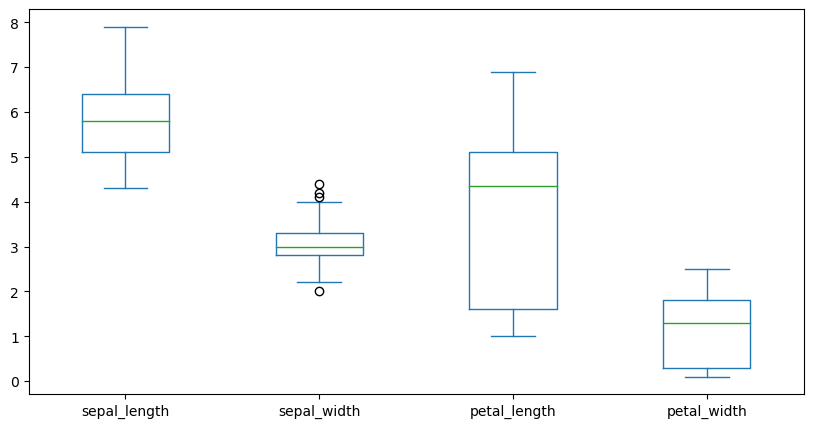

In [159]:
import matplotlib.pyplot as plt
X.plot(kind='box',figsize=(10,5))
plt.show()

In [163]:
X.rolling(5).mean().iloc[4:10] # 추세를 부드럽게 보고 싶을 때 

,sepal_length,sepal_width,petal_length,petal_width
4,4.86,3.28,1.40,0.20
5,4.92,3.36,1.46,0.24
6,4.86,3.44,1.46,0.26
7,4.92,3.48,1.50,0.26
8,4.88,3.44,1.48,0.26
9,4.86,3.34,1.50,0.24


In [164]:
X.iloc[:10]

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


## 8.2 요약통계량

In [165]:
# 1)기본 요약 통계량
iris.describe() # 기본값=> 숫자컬럼에서의 요약 통계량

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [166]:
iris['species'].describe()
iris.species.describe() #문자열에서 요약 통계량 : 데이터 갯수, 종류(unique),최빈값(top), 최빈데이커갯수(freg)

count        150
unique         3
top       setosa
freq          50
Name: species, dtype: object

In [172]:
#2) describe()의 include와 exclude매개 변수
df=pd.DataFrame({'a':[1,2,3]*2,
                 'b':[1.1,2]*3,
                 'c':['aaa','bbb','ccc','aaa','bbb','ccc'],
                 'd':[True,False]*3})
display(df)
df.info()

,a,b,c,d
0,1,1.1,aaa,True
1,2,2.0,bbb,False
2,3,1.1,ccc,True
3,1,2.0,aaa,False
4,2,1.1,bbb,True
5,3,2.0,ccc,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   a       6 non-null      int64  
 1   b       6 non-null      float64
 2   c       6 non-null      object 
 3   d       6 non-null      bool   
dtypes: bool(1), float64(1), int64(1), object(1)
memory usage: 278.0+ bytes


In [173]:
df.describe()#숫자열만 기본 요약통계량 return

,a,b
count,6.000000,6.00000
mean,2.000000,1.55000
std,0.894427,0.49295
min,1.000000,1.10000
25%,1.250000,1.10000
50%,2.000000,1.55000
75%,2.750000,2.00000
max,3.000000,2.00000


In [175]:
# include 매개변수를 통해서 요약 통계량을 출력타입 지정
df.describe(include=['int64','float64','bool'])

,a,b,d
count,6.000000,6.00000,6
unique,NaN,NaN,2
top,NaN,NaN,True
freq,NaN,NaN,3
mean,2.000000,1.55000,NaN
std,0.894427,0.49295,NaN
min,1.000000,1.10000,NaN
25%,1.250000,1.10000,NaN
50%,2.000000,1.55000,NaN
75%,2.750000,2.00000,NaN


In [178]:
# 문자형이나 bool의 요약 통계량
df.describe(include=['object','bool'])

,c,d
count,6,6
unique,3,2
top,aaa,True
freq,2,3


In [179]:
# exclude 매개변수를 이용해서 제외할 타입 지정
df.describe(exclude='float64')

,a,c,d
count,6.000000,6,6
unique,NaN,3,2
top,NaN,aaa,True
freq,NaN,2,3
mean,2.000000,NaN,NaN
std,0.894427,NaN,NaN
min,1.000000,NaN,NaN
25%,1.250000,NaN,NaN
50%,2.000000,NaN,NaN
75%,2.750000,NaN,NaN


In [180]:
df.describe(include='all')#df의 모든열의 요약 통계량 출력

,a,b,c,d
count,6.000000,6.00000,6,6
unique,NaN,NaN,3,2
top,NaN,NaN,aaa,True
freq,NaN,NaN,2,3
mean,2.000000,1.55000,NaN,NaN
std,0.894427,0.49295,NaN,NaN
min,1.000000,1.10000,NaN,NaN
25%,1.250000,1.10000,NaN,NaN
50%,2.000000,1.55000,NaN,NaN
75%,2.750000,2.00000,NaN,NaN


In [181]:
df['c'].unique()#특정 컬럼의 고유값들

array(['aaa', 'bbb', 'ccc'], dtype=object)

In [182]:
df['c'].value_counts() #고유값들의 빈도(내림차순 정렬)

aaa    2
bbb    2
ccc    2
Name: c, dtype: int64

In [183]:
df.select_dtypes(include=object) #해당 타입의 컬럼만 추출

,c
0,aaa
1,bbb
2,ccc
3,aaa
4,bbb
5,ccc


In [184]:
df.select_dtypes(exclude=object)#해당 타입의 컬럼만 제외하고 추출

,a,b,d
0,1,1.1,True
1,2,2.0,False
2,3,1.1,True
3,1,2.0,False
4,2,1.1,True
5,3,2.0,False


## 8.3 공분산,상관계수

In [186]:
# 공분산 : (x1-x1평균)*(x2-x2평균)들의 합을 n-1을 나눈 값
X.cov()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.685694,-0.042434,1.274315,0.516271
sepal_width,-0.042434,0.189979,-0.329656,-0.121639
petal_length,1.274315,-0.329656,3.116278,1.295609
petal_width,0.516271,-0.121639,1.295609,0.581006


In [191]:
# -1< 상관계수(공분산/x1의 표준편차*x2의 표준편차) <1
X.corr()
# X['sepal_length'].var()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


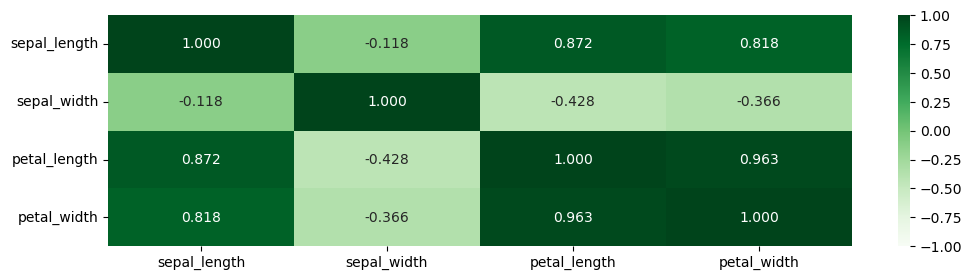

In [196]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,3)) # 그래프 사이즈 조정
sns.heatmap(X.corr(), annot=True, vmin=-1, vmax=1, cmap='Greens', fmt='.3f')
plt.show()

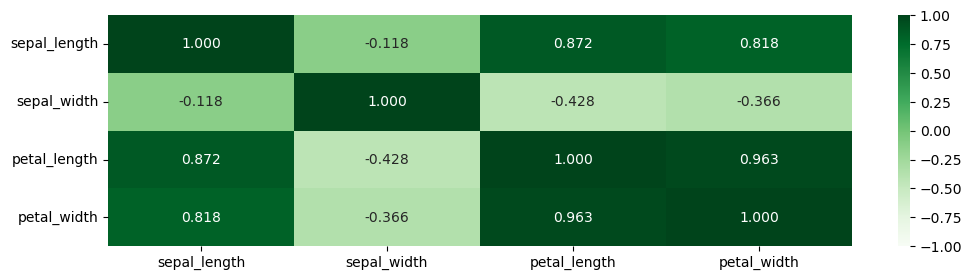

In [197]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,3))# 그래프 사이즈 조정
sns.heatmap(X.corr(), annot=True, vmin=-1, vmax=1,cmap='Greens',fmt='.3f')
plt.show()